# Code-Capacity Damping Heat Maps For Half-Stabilizer Errors

This follows the half-stabilizer memory heat-map notebook closely, but sweeps message-edge damping intervals instead of per-bit memory strengths. The application scope switch keeps the same notebook structure while toggling between all-edge disorder and stabilizer-support-local disorder.


In [1]:
import importlib
from math import comb
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm


c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from relay_bp.analysis.code_capacity_common import default_export_code_paths

CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.10
max_iter = 40
alpha = 1.0
damping_application_scope = "stabilizer_support"  # options: "stabilizer_support", "all_edges"

center_values = np.linspace(0.00, 1.00, 11)
width_values = np.linspace(0.00, 2.00, 11)
random_draws_per_point = 2
base_seed = 0

show_progress = True
show_inner_case_progress = False

selected_row_weights = None  # e.g. {4, 6}
case_limit = None  # set to an integer for a quick smoke run

assert np.all((0.0 <= center_values) & (center_values <= 1.0)), "center_values must stay inside [0, 1]."
assert np.all(width_values >= 0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."


In [4]:
import importlib
from math import comb
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = globals().get("REPO_ROOT", find_repo_root(Path.cwd()))
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import relay_bp.analysis.code_capacity_common as code_capacity_common_module
import relay_bp.analysis.code_capacity_damping as code_capacity_damping_module

importlib.reload(code_capacity_common_module)
importlib.reload(code_capacity_damping_module)

from relay_bp.analysis.code_capacity_common import (
    default_export_code_paths,
    enumerate_half_stabilizer_cases,
    load_code_capacity_problem,
)
from relay_bp.analysis.code_capacity_damping import (
    evaluate_interval_heatmap,
    heatmap_rows,
)

CODE_PATHS = globals().get("CODE_PATHS", default_export_code_paths(REPO_ROOT))
selected_code = globals().get("selected_code", "gross")
npz_path = globals().get("npz_path", CODE_PATHS[selected_code])
prior_error_rate = float(globals().get("prior_error_rate", 0.10))
max_iter = int(globals().get("max_iter", 40))
alpha = float(globals().get("alpha", 1.0))
damping_application_scope = globals().get("damping_application_scope", "stabilizer_support")
center_values = np.asarray(globals().get("center_values", np.linspace(0.50, 1.00, 11)), dtype=np.float64)
width_values = np.asarray(globals().get("width_values", np.linspace(0.00, 0.50, 11)), dtype=np.float64)
random_draws_per_point = int(globals().get("random_draws_per_point", 2))
base_seed = int(globals().get("base_seed", 0))
show_progress = bool(globals().get("show_progress", False))
show_inner_case_progress = bool(globals().get("show_inner_case_progress", False))
selected_row_weights = globals().get("selected_row_weights", None)
case_limit = globals().get("case_limit", None)


def load_css_code(path: Path) -> dict[str, object]:
    problem = load_code_capacity_problem(path, default_prior_error_rate=prior_error_rate)
    return {
        "problem": problem,
        "hx": problem.hx,
        "hz": problem.hz,
        "lz": problem.lz,
        "metadata": problem.metadata,
    }


def stabilizer_statistics(hx: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = hx.sum(axis=1).astype(int)
    unique_weights, counts = np.unique(weights, return_counts=True)
    rows = []
    total_even_weight_stabilizers = 0
    total_half_flip_patterns = 0
    for weight, count in zip(unique_weights, counts):
        weight = int(weight)
        count = int(count)
        is_even = weight > 0 and weight % 2 == 0
        half_subsets_per_row = comb(weight, weight // 2) if is_even else 0
        total_half = count * half_subsets_per_row
        if is_even:
            total_even_weight_stabilizers += count
            total_half_flip_patterns += total_half
        rows.append(
            {
                "row_weight": weight,
                "n_x_stabilizers": count,
                "is_even_weight": is_even,
                "half_flip_patterns_per_row": half_subsets_per_row,
                "total_half_flip_patterns": total_half,
            }
        )
    summary = pd.DataFrame(
        [
            {
                "code": selected_code,
                "Hx_rows": int(hx.shape[0]),
                "n_qubits": int(hx.shape[1]),
                "even_weight_x_stabilizers": total_even_weight_stabilizers,
                "total_half_flip_patterns": total_half_flip_patterns,
            }
        ]
    )
    return pd.DataFrame(rows), summary


def case_manifest(cases: list[dict[str, object]], head: int | None = 20) -> pd.DataFrame:
    manifest = pd.DataFrame(
        [
            {
                "case_id": int(case["case_id"]),
                "row_idx": int(case["row_idx"]),
                "row_weight": int(case["row_weight"]),
                "half_subset_idx": int(case["half_subset_idx"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "support_bits": list(case["support_bits"]),
                "flipped_bits": list(case["flipped_bits"]),
            }
            for case in cases
        ]
    )
    return manifest.head(head) if head is not None else manifest


def evaluate_parameter_heatmaps(cases: list[dict[str, object]], check_matrix, lz_matrix) -> dict[str, object]:
    del check_matrix, lz_matrix
    return evaluate_interval_heatmap(
        problem=code_data["problem"],
        cases=cases,
        max_iter=max_iter,
        alpha=alpha,
        centers=center_values.tolist(),
        widths=width_values.tolist(),
        base_seed=base_seed,
        random_draws_per_point=random_draws_per_point,
        support_only=damping_application_scope == "stabilizer_support",
        show_progress=show_progress,
        show_inner_case_progress=show_inner_case_progress,
    )


def grid_table(artifact: dict[str, object]) -> pd.DataFrame:
    return pd.DataFrame(heatmap_rows(artifact)).sort_values(
        ["logical_success_rate", "convergence_rate", "exact_recovery_rate", "mean_iterations"],
        ascending=[False, False, False, True],
    )


def best_points_table(artifact: dict[str, object], top_k: int = 8) -> pd.DataFrame:
    return grid_table(artifact).head(int(top_k)).reset_index(drop=True)


def plot_parameter_heatmaps(artifact: dict[str, object]):
    metrics = [
        ("logical_success_rate", "Logical success rate"),
        ("convergence_rate", "Convergence rate"),
        ("exact_recovery_rate", "Exact recovery rate"),
        ("mean_iterations", "Mean iterations"),
    ]
    centers = np.asarray(artifact["centers"], dtype=np.float64)
    widths = np.asarray(artifact["widths"], dtype=np.float64)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for axis, (metric_key, title) in zip(axes.flat, metrics):
        image = axis.imshow(
            np.asarray(artifact[metric_key], dtype=np.float64),
            origin="lower",
            aspect="auto",
            extent=[float(centers.min()), float(centers.max()), float(widths.min()), float(widths.max())],
            cmap="viridis",
        )
        axis.set_title(title)
        axis.set_xlabel("interval center")
        axis.set_ylabel("interval width")
        fig.colorbar(image, ax=axis, shrink=0.85)
    fig.suptitle(
        f"{selected_code}: half-stabilizer damping heat maps ({damping_application_scope})",
        fontsize=14,
    )
    return fig


code_data = load_css_code(npz_path)
hz_check_matrix = code_data["hz"]
lz_matrix = code_data["lz"]
stabilizer_rows, stabilizer_summary = stabilizer_statistics(code_data["hx"])
all_cases = enumerate_half_stabilizer_cases(
    code_data["problem"],
    selected_row_weights=None if selected_row_weights is None else set(int(weight) for weight in selected_row_weights),
    max_cases=case_limit,
)
case_manifest_df = case_manifest(all_cases)


_smoke_code_data = load_css_code(CODE_PATHS["surface13"])
_smoke_cases = enumerate_half_stabilizer_cases(_smoke_code_data["problem"], max_cases=4)
_smoke_artifact = evaluate_interval_heatmap(
    problem=_smoke_code_data["problem"],
    cases=_smoke_cases,
    max_iter=8,
    alpha=1.0,
    centers=[0.75],
    widths=[0.10],
    base_seed=3,
    random_draws_per_point=1,
    support_only=True,
)
assert _smoke_artifact["logical_success_rate"].shape == (1, 1)
assert int(_smoke_artifact["trial_count"][0, 0]) == len(_smoke_cases)


## Half-Stabilizer Catalogue


In [5]:
display(stabilizer_summary)
display(stabilizer_rows)
display(case_manifest_df)


,code,Hx_rows,n_qubits,even_weight_x_stabilizers,total_half_flip_patterns
0,gross,72,144,72,1440


,row_weight,n_x_stabilizers,is_even_weight,half_flip_patterns_per_row,total_half_flip_patterns
0,6,72,True,20,1440


,case_id,row_idx,row_weight,half_subset_idx,syndrome_weight,support_bits,flipped_bits
0,0,0,6,0,9,"[1, 2, 18, 75, 78, 84]","[1, 2, 18]"
1,1,0,6,1,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 75]"
2,2,0,6,2,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 78]"
3,3,0,6,3,5,"[1, 2, 18, 75, 78, 84]","[1, 2, 84]"
4,4,0,6,4,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 75]"
5,5,0,6,5,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 78]"
6,6,0,6,6,5,"[1, 2, 18, 75, 78, 84]","[1, 18, 84]"
7,7,0,6,7,5,"[1, 2, 18, 75, 78, 84]","[1, 75, 78]"
8,8,0,6,8,5,"[1, 2, 18, 75, 78, 84]","[1, 75, 84]"
9,9,0,6,9,5,"[1, 2, 18, 75, 78, 84]","[1, 78, 84]"


## Coefficient Heat Maps


heatmap grid: 100%|██████████| 121/121 [01:33<00:00,  1.29it/s, center=1.000, conv=1.000, logical=1.000, width=2.000]


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
0,0.7,2.0,0.0,1.0,1.0,1.0,0.531944,2.485417,2880
1,0.1,1.0,0.0,0.6,1.0,1.0,0.522917,2.873611,2880
2,0.3,1.8,0.0,1.0,1.0,1.0,0.522222,2.456250,2880
3,0.4,1.0,0.0,0.9,1.0,1.0,0.518056,2.388889,2880
4,0.5,1.2,0.0,1.0,1.0,1.0,0.518056,2.417014,2880
5,0.7,0.6,0.4,1.0,1.0,1.0,0.517361,4.311458,2880
6,0.4,0.2,0.3,0.5,1.0,1.0,0.516667,2.979167,2880
7,0.4,1.2,0.0,1.0,1.0,1.0,0.515972,2.410764,2880


,center,width,low,high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,trial_count
117,0.7,2.0,0.0,1.0,1.0,1.0,0.531944,2.485417,2880
56,0.1,1.0,0.0,0.6,1.0,1.0,0.522917,2.873611,2880
102,0.3,1.8,0.0,1.0,1.0,1.0,0.522222,2.456250,2880
59,0.4,1.0,0.0,0.9,1.0,1.0,0.518056,2.388889,2880
71,0.5,1.2,0.0,1.0,1.0,1.0,0.518056,2.417014,2880
40,0.7,0.6,0.4,1.0,1.0,1.0,0.517361,4.311458,2880
15,0.4,0.2,0.3,0.5,1.0,1.0,0.516667,2.979167,2880
70,0.4,1.2,0.0,1.0,1.0,1.0,0.515972,2.410764,2880
76,1.0,1.2,0.4,1.0,1.0,1.0,0.515972,4.267361,2880
29,0.7,0.4,0.5,0.9,1.0,1.0,0.515972,4.386111,2880


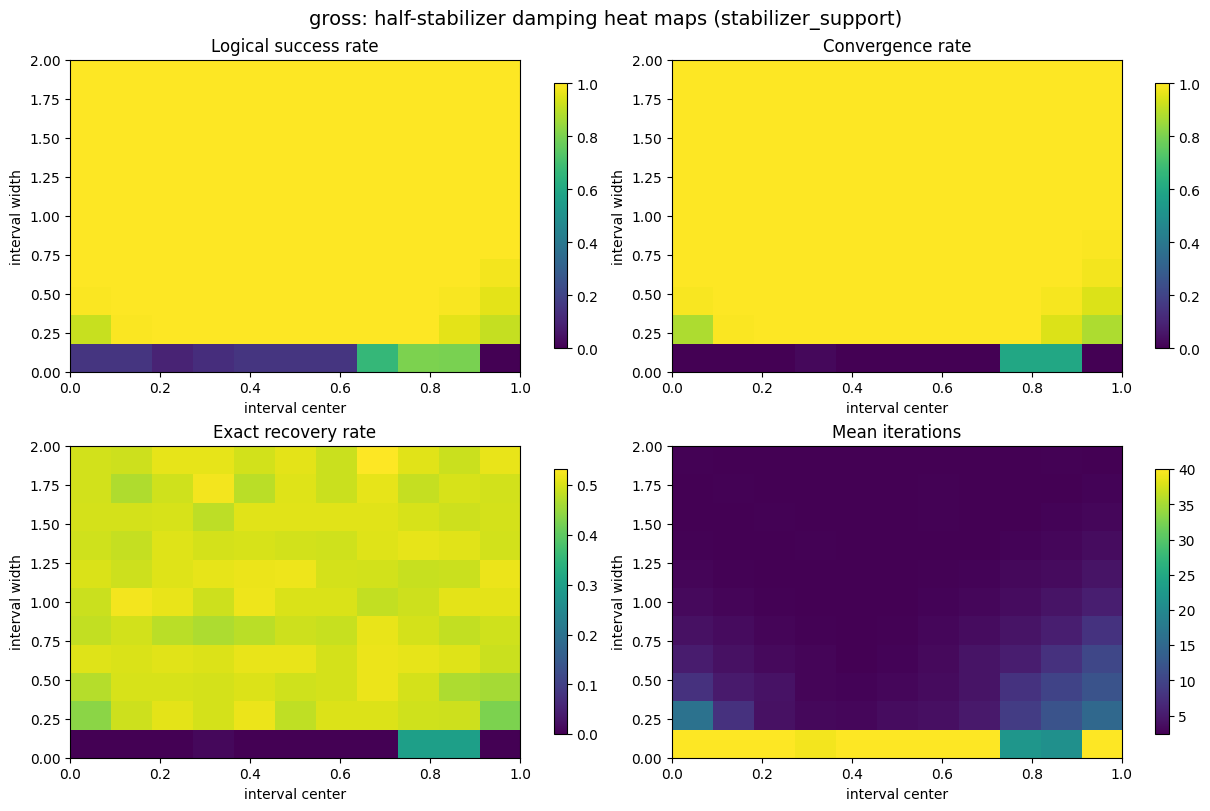

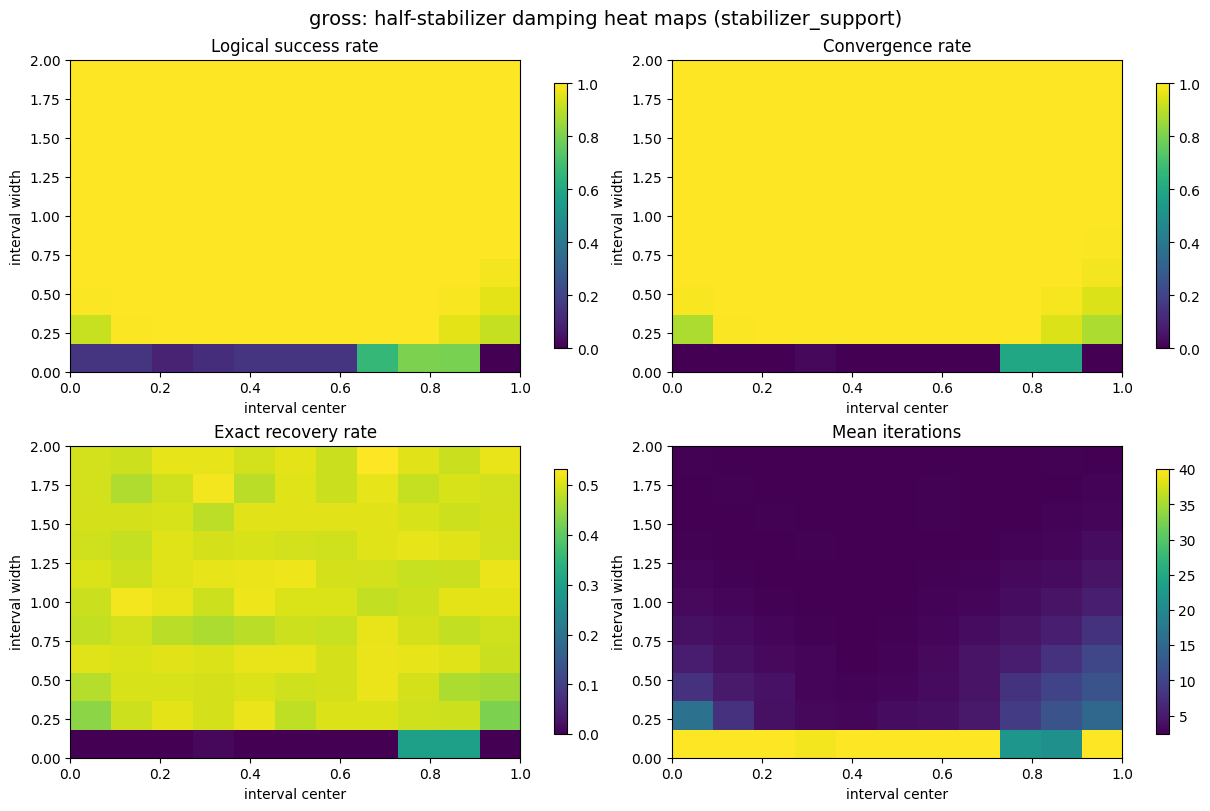

In [6]:
artifact = evaluate_parameter_heatmaps(all_cases, hz_check_matrix, lz_matrix)
heatmap_df = grid_table(artifact)
best_points_df = best_points_table(artifact)

display(best_points_df)
display(heatmap_df.head(16))
fig = plot_parameter_heatmaps(artifact)
fig


## Optional Extension

A useful end-of-notebook comparison is to take the best point from the chosen application scope and rerun it under the other scope. That tells you whether the gain came from the interval values themselves or from keeping the disorder local to the half-stabilizer support.


In [7]:
best_point = best_points_df.iloc[0]
alternate_scope_artifact = evaluate_interval_heatmap(
    problem=code_data["problem"],
    cases=all_cases,
    max_iter=max_iter,
    alpha=alpha,
    centers=[float(best_point["center"])],
    widths=[float(best_point["width"])],
    base_seed=base_seed,
    random_draws_per_point=random_draws_per_point,
    support_only=not (damping_application_scope == "stabilizer_support"),
    show_progress=show_progress,
    show_inner_case_progress=show_inner_case_progress,
)
alternate_row = pd.DataFrame(heatmap_rows(alternate_scope_artifact)).iloc[0]
comparison_df = pd.DataFrame(
    [
        {
            "scope": damping_application_scope,
            "center": float(best_point["center"]),
            "width": float(best_point["width"]),
            "logical_success_rate": float(best_point["logical_success_rate"]),
            "exact_recovery_rate": float(best_point["exact_recovery_rate"]),
            "mean_iterations": float(best_point["mean_iterations"]),
        },
        {
            "scope": "all_edges" if damping_application_scope == "stabilizer_support" else "stabilizer_support",
            "center": float(alternate_row["center"]),
            "width": float(alternate_row["width"]),
            "logical_success_rate": float(alternate_row["logical_success_rate"]),
            "exact_recovery_rate": float(alternate_row["exact_recovery_rate"]),
            "mean_iterations": float(alternate_row["mean_iterations"]),
        },
    ]
)
display(comparison_df)


heatmap grid: 100%|██████████| 1/1 [00:02<00:00,  2.03s/it, center=0.700, conv=1.000, logical=1.000, width=2.000]


,scope,center,width,logical_success_rate,exact_recovery_rate,mean_iterations
0,stabilizer_support,0.7,2.0,1.0,0.531944,2.485417
1,all_edges,0.7,2.0,1.0,0.509028,2.421181
